In [1]:
import zipfile
import os

def unzip_file(zip_path, extract_to):
    # 检查目标目录是否存在，不存在则创建
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    
    # 解压缩文件
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("解压缩完成！")

# 示例使用
zip_path = '/root/autodl-fs/archive.zip'  # 压缩文件路径
extract_to = 'Data'  # 目标存储路径

unzip_file(zip_path, extract_to)


解压缩完成！


2024-12-19 10:23:59.127787: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-19 10:24:01.533646: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-19 10:24:02.186383: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:1b:00.0, compute capability: 8.9


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 256, 256, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 64  256        ['conv2d_1[0][0]']               
 alization)                     )                                                             

2024-12-19 10:24:10.359358: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2024-12-19 10:24:11.312497: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2024-12-19 10:24:11.312515: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2024-12-19 10:24:11.312573: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2024-12-19 10:24:12.173468: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


20/20 [==============================] - 15s 258ms/step - loss: 0.3121 - accuracy: 0.8526 - val_loss: 0.5548 - val_accuracy: 0.8661
Epoch 2/50
20/20 [==============================] - 4s 190ms/step - loss: 0.1844 - accuracy: 0.9080 - val_loss: 0.6437 - val_accuracy: 0.8386
Epoch 3/50
20/20 [==============================] - 4s 190ms/step - loss: 0.1646 - accuracy: 0.9226 - val_loss: 0.7810 - val_accuracy: 0.8671
Epoch 4/50
20/20 [==============================] - 4s 190ms/step - loss: 0.1423 - accuracy: 0.9322 - val_loss: 0.3289 - val_accuracy: 0.8563
Epoch 5/50
20/20 [==============================] - 4s 190ms/step - loss: 0.1249 - accuracy: 0.9405 - val_loss: 0.3153 - val_accuracy: 0.8592
Epoch 6/50
20/20 [==============================] - 4s 189ms/step - loss: 0.0962 - accuracy: 0.9518 - val_loss: 0.2736 - val_accuracy: 0.8669
Epoch 7/50
20/20 [==============================] - 4s 190ms/step - loss: 0.0813 - accuracy: 0.9579 - val_loss: 0.3341 - val_accuracy: 0.8653
Epoch 8/50
20/20

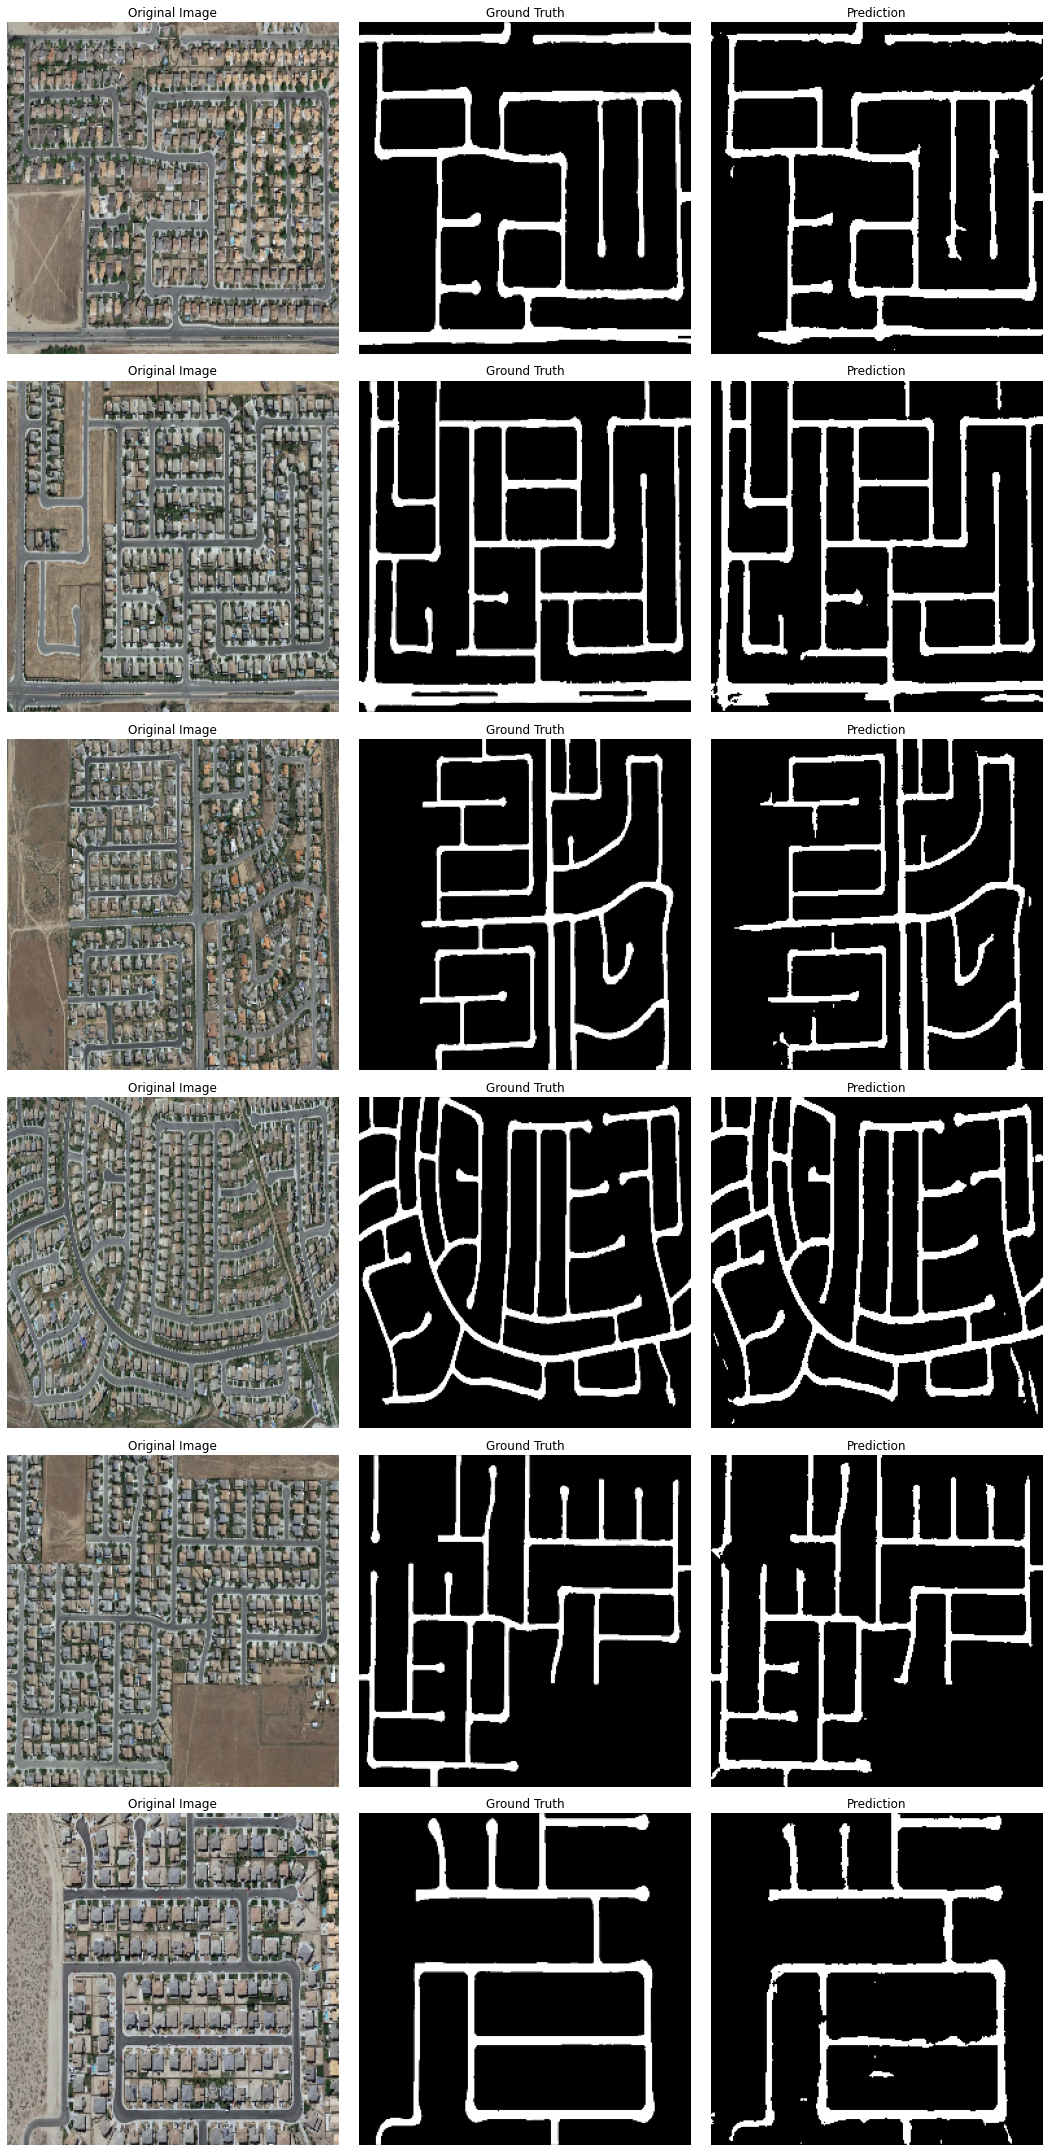

1/1 [==============================] - 0s 73ms/step
IoU: 0.8675
Dice Coefficient: 0.8750
Accuracy: 0.9629
Precision: 0.9153
Recall: 0.8380
F1 Score: 0.8750
Overall Accuracy (OA): 0.9629
Kappa Coefficient: 0.8532


In [5]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.metrics import MeanIoU

# 数据集路径
data_dir = "Data"

# 自定义数据集加载
class RoadDataset(tf.keras.utils.Sequence):
    def __init__(self, folder, batch_size, img_size=(256, 256), shuffle=True):
        self.image_dir = os.path.join(folder, "image")
        self.label_dir = os.path.join(folder, "label")
        self.image_paths = sorted(os.listdir(self.image_dir))
        self.label_paths = sorted(os.listdir(self.label_dir))
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        images, labels = [], []
        for i in batch_indices:
            image = cv2.imread(os.path.join(self.image_dir, self.image_paths[i]), cv2.IMREAD_COLOR)
            label = cv2.imread(os.path.join(self.label_dir, self.label_paths[i]), cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, self.img_size)
            label = cv2.resize(label, self.img_size)
            images.append(image / 255.0)
            labels.append(label / 255.0)
        return np.array(images, dtype=np.float32), np.expand_dims(np.array(labels, dtype=np.float32), axis=-1)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

# 定义 Residual Block
def residual_block(x, filters):
    shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x

# 定义 Attention Block
def attention_block(x, g, inter_channels):
    theta_x = layers.Conv2D(inter_channels, (1, 1), padding="same")(x)
    phi_g = layers.Conv2D(inter_channels, (1, 1), padding="same")(g)
    f = layers.Activation("relu")(layers.Add()([theta_x, phi_g]))
    psi_f = layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(f)
    return layers.Multiply()([x, psi_f])

# 引入深度可分离卷积和多尺度卷积
def local_stream_advanced(x, filters):
    # 多尺度卷积：不同尺度的卷积操作并行
    conv1 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(1, 1))(x)  # 标准卷积
    conv2 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(2, 2))(x)  # 空洞卷积
    conv3 = layers.Conv2D(filters, (5, 5), padding="same", dilation_rate=(1, 1))(x)  # 大卷积核

    # 合并多尺度卷积
    x_multi_scale = layers.Concatenate(axis=-1)([conv1, conv2, conv3])

    # 使用深度可分离卷积
    x_separable = layers.SeparableConv2D(filters, (3, 3), padding="same")(x_multi_scale)
    x_separable = layers.BatchNormalization()(x_separable)
    x_separable = layers.ReLU()(x_separable)

    # 残差连接
    shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Add()([shortcut, x_separable])
    x = layers.ReLU()(x)
    return x

# Swin Transformer Block 的实现
class SwinTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, window_size=8, shift_size=4, **kwargs):
        super(SwinTransformerBlock, self).__init__(**kwargs)
        assert 0 <= shift_size < window_size, "shift_size must be in 0 <= shift_size < window_size"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.drop_path = layers.Dropout(0.1)  # Drop path rate can be adjusted
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(embed_dim * 4, activation='gelu'),
            layers.Dense(embed_dim)
        ])
        self.dropout = layers.Dropout(0.1)

    def window_partition(self, x):
        # x: (batch, height, width, channels)
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        x = tf.reshape(x, (batch, height // self.window_size, self.window_size, width // self.window_size, self.window_size, channels))
        windows = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, num_windows_w, window_size, window_size, channels)
        windows = tf.reshape(windows, (-1, self.window_size * self.window_size, channels))  # (batch*num_windows, window_size*window_size, channels)
        return windows

    def window_reverse(self, windows, height, width):
        # windows: (batch*num_windows, window_size*window_size, channels)
        batch = tf.shape(windows)[0] // (height // self.window_size * width // self.window_size)
        x = tf.reshape(windows, (batch, height // self.window_size, width // self.window_size, self.window_size, self.window_size, self.embed_dim))
        x = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, window_size, num_windows_w, window_size, channels)
        x = tf.reshape(x, (batch, height, width, self.embed_dim))
        return x

    def call(self, x):
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        # Shifted Window
        if self.shift_size > 0:
            shifted_x = tf.roll(x, shift=(-self.shift_size, -self.shift_size), axis=(1, 2))
        else:
            shifted_x = x

        # Partition windows
        windows = self.window_partition(shifted_x)  # (batch*num_windows, window_size*window_size, channels)

        # Multi-Head Self-Attention
        windows_norm = self.norm1(windows)
        attn_output = self.attn(windows_norm, windows_norm)  # (batch*num_windows, window_size*window_size, channels)
        attn_output = self.drop_path(attn_output)
        windows = windows + attn_output  # Residual connection

        # MLP
        windows_norm = self.norm2(windows)
        mlp_output = self.mlp(windows_norm)
        mlp_output = self.dropout(mlp_output)
        windows = windows + mlp_output  # Residual connection

        # Reverse windows
        x = self.window_reverse(windows, height, width)  # (batch, height, width, channels)

        # Reverse shift
        if self.shift_size > 0:
            x = tf.roll(x, shift=(self.shift_size, self.shift_size), axis=(1, 2))

        return x

# 图神经网络（GNN）模块的实现（Graph Attention Network）
class GraphAttentionBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1, **kwargs):
        super(GraphAttentionBlock, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout_rate)
        self.activation = layers.Activation('relu')

    def call(self, x):
        # x: (batch, num_nodes, embed_dim)
        x_norm = self.norm(x)
        attn_output = self.attention(x_norm, x_norm)  # (batch, num_nodes, embed_dim)
        attn_output = self.dropout(attn_output)
        x = self.activation(x + attn_output)  # Residual connection and activation
        return x

# 可学习的空间注意力
class LearnableSpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(LearnableSpatialAttention, self).__init__(**kwargs)
        self.conv = layers.Conv2D(1, (1, 1), activation="sigmoid")

    def call(self, x):
        attention_map = self.conv(x)  # (batch, height, width, 1)
        return layers.Multiply()([x, attention_map])

# 自定义 GlobalStreamAdvanced 层
class GlobalStreamAdvanced(layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, window_size=8, shift_size=4, **kwargs):
        super(GlobalStreamAdvanced, self).__init__(**kwargs)
        self.conv = layers.Conv2D(embed_dim, (1, 1), padding="same")
        self.swin_block = SwinTransformerBlock(embed_dim, num_heads, window_size=window_size, shift_size=shift_size)
        self.gnn_block = GraphAttentionBlock(embed_dim, num_heads=num_heads)

    def call(self, x):
        x = self.conv(x)  # (batch, height, width, embed_dim)
        x = self.swin_block(x)  # (batch, height, width, embed_dim)

        # Reshape to graph format: (batch, num_nodes, embed_dim)
        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]
        embed_dim = tf.shape(x)[3]
        num_nodes = height * width
        x_graph = tf.reshape(x, (batch_size, num_nodes, embed_dim))  # (batch, num_nodes, embed_dim)

        # GNN Module
        x_graph = self.gnn_block(x_graph)  # (batch, num_nodes, embed_dim)

        # Reshape back to feature map: (batch, height, width, embed_dim)
        x = tf.reshape(x_graph, (batch_size, height, width, embed_dim))
        return x

# Global Stream 架构
def global_stream(x, embed_dim=64, num_heads=4, window_size=8, shift_size=4):
    global_stream_layer = GlobalStreamAdvanced(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, shift_size=shift_size)
    return global_stream_layer(x)

# 定义融合模块
def fusion_module(local_features, global_features):
    # 拼接
    fused = layers.Concatenate(axis=-1)([local_features, global_features])
    return fused

# 定义双流网络的U-Net模型
def dual_stream_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Downsampling部分
    c1 = residual_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = residual_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Local and Global Stream 提取特征
    c3_local = local_stream_advanced(p2, 256)  # 使用新的局部特征提取
    c3_global = global_stream(p2, embed_dim=64, num_heads=4, window_size=8, shift_size=4)  # 使用全新的全局特征提取
    c3_fused = fusion_module(c3_local, c3_global)
    p3 = layers.MaxPooling2D((2, 2))(c3_fused)

    c4_local = local_stream_advanced(p3, 512)  # 使用新的局部特征提取
    c4_global = global_stream(p3, embed_dim=64, num_heads=4, window_size=8, shift_size=4)  # 使用全新的全局特征提取
    c4_fused = fusion_module(c4_local, c4_global)
    p4 = layers.MaxPooling2D((2, 2))(c4_fused)

    c5_local = local_stream_advanced(p4, 1024)  # 使用新的局部特征提取
    c5_global = global_stream(p4, embed_dim=64, num_heads=4, window_size=8, shift_size=4)  # 使用全新的全局特征提取
    c5_fused = fusion_module(c5_local, c5_global)

    # Upsampling with Attention
    u4 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(c5_fused)
    u4 = layers.Concatenate(axis=-1)([u4, c4_fused])
    u4 = residual_block(u4, 512)

    u3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(u4)
    u3 = layers.Concatenate(axis=-1)([u3, c3_fused])
    u3 = residual_block(u3, 256)

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(u3)
    u2 = layers.Concatenate(axis=-1)([u2, c2])
    u2 = residual_block(u2, 128)

    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(u2)
    u1 = layers.Concatenate(axis=-1)([u1, c1])
    u1 = residual_block(u1, 64)

    # 可学习的空间注意力
    u1 = LearnableSpatialAttention()(u1)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(u1)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# 初始化数据
batch_size = 8
train_dataset = RoadDataset(os.path.join(data_dir, "Train"), batch_size=batch_size)
val_dataset = RoadDataset(os.path.join(data_dir, "Validation"), batch_size=batch_size)
test_dataset = RoadDataset(os.path.join(data_dir, "Test"), batch_size=batch_size)

# 构建和编译模型
model = dual_stream_unet()
model.compile(optimizer='adam', 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), 
              metrics=['accuracy'])

# 打印模型摘要以验证结构
model.summary()

# 训练模型
model.fit(train_dataset, validation_data=val_dataset, epochs=50)

# 进行可视化
def visualize_predictions(model, dataset, indices=None):
    if indices is None:
        raise ValueError("Please provide a list of indices to visualize specific images.")
    
    num_samples = len(indices)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for idx, img_idx in enumerate(indices):
        # 手动加载指定索引的图片和标签
        image_path = os.path.join(dataset.image_dir, dataset.image_paths[img_idx])
        label_path = os.path.join(dataset.label_dir, dataset.label_paths[img_idx])
        
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, dataset.img_size) / 255.0
        label = cv2.resize(label, dataset.img_size) / 255.0
        
        # 预测结果
        predictions = model.predict(np.expand_dims(image, axis=0))
        prediction = (predictions[0, :, :, 0] > 0.5).astype(np.uint8)

        # 原始图像
        axes[idx, 0].imshow(cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[idx, 0].set_title("Original Image")
        axes[idx, 0].axis("off")

        # 标签图像
        axes[idx, 1].imshow(label, cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        # 预测结果图像
        axes[idx, 2].imshow(prediction, cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

# 指定要可视化的6组图片索引
fixed_indices = [0, 1, 2, 3, 4, 5]
visualize_predictions(model, test_dataset, indices=fixed_indices)

# 定义评估指标
def calculate_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.int32)
    y_true = y_true.astype(np.int32)

    iou_metric = MeanIoU(num_classes=2)
    iou_metric.update_state(y_true, y_pred)
    iou = iou_metric.result().numpy()

    dice = (2 * np.sum(y_pred[y_true == 1]) + 1e-7) / (np.sum(y_pred) + np.sum(y_true) + 1e-7)

    confusion = confusion_matrix(y_true.flatten(), y_pred.flatten())
    accuracy = np.trace(confusion) / np.sum(confusion)
    precision = confusion[1, 1] / (confusion[1, 1] + confusion[0, 1] + 1e-7)
    recall = confusion[1, 1] / (confusion[1, 1] + confusion[1, 0] + 1e-7)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    oa = accuracy  # Overall Accuracy
    pe = np.sum(np.sum(confusion, axis=0) * np.sum(confusion, axis=1)) / (np.sum(confusion) ** 2 + 1e-7)
    kappa = (oa - pe) / (1 - pe + 1e-7)

    return {
        "IoU": iou,
        "Dice Coefficient": dice,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1_score,
        "Overall Accuracy (OA)": oa,
        "Kappa Coefficient": kappa
    }

# 测试模型并计算评估指标
y_true_list, y_pred_list = [], []
for images, labels in test_dataset:
    predictions = model.predict(images)
    y_true_list.append(labels)
    y_pred_list.append(predictions)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

metrics = calculate_metrics(y_true, y_pred)
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.metrics import MeanIoU
import itertools

# 设置随机种子以确保结果可重复
np.random.seed(42)
tf.random.set_seed(42)

# 数据集路径
data_dir = "Data"

# 自定义数据集加载
class RoadDataset(tf.keras.utils.Sequence):
    def __init__(self, folder, batch_size, img_size=(256, 256), shuffle=True):
        self.image_dir = os.path.join(folder, "image")
        self.label_dir = os.path.join(folder, "label")
        self.image_paths = sorted(os.listdir(self.image_dir))
        self.label_paths = sorted(os.listdir(self.label_dir))
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        images, labels = [], []
        for i in batch_indices:
            image = cv2.imread(os.path.join(self.image_dir, self.image_paths[i]), cv2.IMREAD_COLOR)
            label = cv2.imread(os.path.join(self.label_dir, self.label_paths[i]), cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, self.img_size)
            label = cv2.resize(label, self.img_size)
            images.append(image / 255.0)
            labels.append(label / 255.0)
        return np.array(images, dtype=np.float32), np.expand_dims(np.array(labels, dtype=np.float32), axis=-1)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

# 定义 Residual Block
def residual_block(x, filters, use_residual=True):
    shortcut = x
    if use_residual:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    if use_residual:
        x = layers.Add()([shortcut, x])
    else:
        x = layers.Add()([x, shortcut])  # 保持结构一致
    x = layers.ReLU()(x)
    return x

# 定义 Attention Block
def attention_block(x, g, inter_channels, use_attention=True):
    if not use_attention:
        return x
    theta_x = layers.Conv2D(inter_channels, (1, 1), padding="same")(x)
    phi_g = layers.Conv2D(inter_channels, (1, 1), padding="same")(g)
    f = layers.Activation("relu")(layers.Add()([theta_x, phi_g]))
    psi_f = layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(f)
    return layers.Multiply()([x, psi_f])

# 引入深度可分离卷积和多尺度卷积
def local_stream_advanced(x, filters, use_attention=False, use_separable=True):
    # 多尺度卷积：不同尺度的卷积操作并行
    conv1 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(1, 1))(x)  # 标准卷积
    conv2 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(2, 2))(x)  # 空洞卷积
    conv3 = layers.Conv2D(filters, (5, 5), padding="same", dilation_rate=(1, 1))(x)  # 大卷积核

    # 合并多尺度卷积
    x_multi_scale = layers.Concatenate(axis=-1)([conv1, conv2, conv3])

    # 使用深度可分离卷积
    if use_separable:
        x_separable = layers.SeparableConv2D(filters, (3, 3), padding="same")(x_multi_scale)
    else:
        x_separable = layers.Conv2D(filters, (3, 3), padding="same")(x_multi_scale)
    x_separable = layers.BatchNormalization()(x_separable)
    x_separable = layers.ReLU()(x_separable)

    # 残差连接
    shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Add()([shortcut, x_separable])
    x = layers.ReLU()(x)
    return x

# Swin Transformer Block 的实现
class SwinTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, window_size=8, shift_size=4, use_swin=True, **kwargs):
        super(SwinTransformerBlock, self).__init__(**kwargs)
        self.use_swin = use_swin
        if not self.use_swin:
            return  # 如果不使用Swin Transformer，则不初始化相关层

        assert 0 <= shift_size < window_size, "shift_size must be in 0 <= shift_size < window_size"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.drop_path = layers.Dropout(0.1)  # Drop path rate can be adjusted
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(embed_dim * 4, activation='gelu'),
            layers.Dense(embed_dim)
        ])
        self.dropout = layers.Dropout(0.1)

    def window_partition(self, x):
        # x: (batch, height, width, channels)
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        x = tf.reshape(x, (batch, height // self.window_size, self.window_size, width // self.window_size, self.window_size, channels))
        windows = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, num_windows_w, window_size, window_size, channels)
        windows = tf.reshape(windows, (-1, self.window_size * self.window_size, channels))  # (batch*num_windows, window_size*window_size, channels)
        return windows

    def window_reverse(self, windows, height, width):
        # windows: (batch*num_windows, window_size*window_size, channels)
        batch = tf.shape(windows)[0] // (height // self.window_size * width // self.window_size)
        x = tf.reshape(windows, (batch, height // self.window_size, width // self.window_size, self.window_size, self.window_size, self.embed_dim))
        x = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, window_size, num_windows_w, window_size, channels)
        x = tf.reshape(x, (batch, height, width, self.embed_dim))
        return x

    def call(self, x):
        if not self.use_swin:
            return x  # 如果不使用Swin Transformer，则直接返回输入

        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        # Shifted Window
        if self.shift_size > 0:
            shifted_x = tf.roll(x, shift=(-self.shift_size, -self.shift_size), axis=(1, 2))
        else:
            shifted_x = x

        # Partition windows
        windows = self.window_partition(shifted_x)  # (batch*num_windows, window_size*window_size, channels)

        # Multi-Head Self-Attention
        windows_norm = self.norm1(windows)
        attn_output = self.attn(windows_norm, windows_norm)  # (batch*num_windows, window_size*window_size, channels)
        attn_output = self.drop_path(attn_output)
        windows = windows + attn_output  # Residual connection

        # MLP
        windows_norm = self.norm2(windows)
        mlp_output = self.mlp(windows_norm)
        mlp_output = self.dropout(mlp_output)
        windows = windows + mlp_output  # Residual connection

        # Reverse windows
        x = self.window_reverse(windows, height, width)  # (batch, height, width, channels)

        # Reverse shift
        if self.shift_size > 0:
            x = tf.roll(x, shift=(self.shift_size, self.shift_size), axis=(1, 2))

        return x

    def get_config(self):
        config = super(SwinTransformerBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "window_size": self.window_size,
            "shift_size": self.shift_size,
            "use_swin": self.use_swin
        })
        return config

# 图神经网络（GNN）模块的实现（Graph Attention Network）
class GraphAttentionBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1, use_gnn=True, **kwargs):
        super(GraphAttentionBlock, self).__init__(**kwargs)
        self.use_gnn = use_gnn
        if not self.use_gnn:
            return  # 如果不使用GNN，则不初始化相关层

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout_rate)
        self.activation = layers.Activation('relu')

    def call(self, x):
        if not self.use_gnn:
            return x  # 如果不使用GNN，则直接返回输入

        # x: (batch, num_nodes, embed_dim)
        x_norm = self.norm(x)
        attn_output = self.attention(x_norm, x_norm)  # (batch, num_nodes, embed_dim)
        attn_output = self.dropout(attn_output)
        x = self.activation(x + attn_output)  # Residual connection and activation
        return x

    def get_config(self):
        config = super(GraphAttentionBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout.rate,
            "use_gnn": self.use_gnn
        })
        return config

# 可学习的空间注意力
class LearnableSpatialAttention(layers.Layer):
    def __init__(self, use_spatial_attention=True, **kwargs):
        super(LearnableSpatialAttention, self).__init__(**kwargs)
        self.use_spatial_attention = use_spatial_attention
        if not self.use_spatial_attention:
            return  # 如果不使用空间注意力，则不初始化相关层
        self.conv = layers.Conv2D(1, (1, 1), activation="sigmoid")

    def call(self, x):
        if not self.use_spatial_attention:
            return x  # 如果不使用空间注意力，则直接返回输入
        attention_map = self.conv(x)  # (batch, height, width, 1)
        return layers.Multiply()([x, attention_map])

    def get_config(self):
        config = super(LearnableSpatialAttention, self).get_config()
        config.update({
            "use_spatial_attention": self.use_spatial_attention
        })
        return config

# 自定义 GlobalStreamAdvanced 层
class GlobalStreamAdvanced(layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, window_size=8, shift_size=4, use_swin=True, use_gnn=True, **kwargs):
        super(GlobalStreamAdvanced, self).__init__(**kwargs)
        self.use_swin = use_swin
        self.use_gnn = use_gnn
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.conv = layers.Conv2D(embed_dim, (1, 1), padding="same")
        self.swin_block = SwinTransformerBlock(embed_dim, num_heads, window_size=window_size, shift_size=shift_size, use_swin=use_swin)
        self.gnn_block = GraphAttentionBlock(embed_dim, num_heads=num_heads, use_gnn=use_gnn)

    def call(self, x):
        x = self.conv(x)  # (batch, height, width, embed_dim)
        x = self.swin_block(x)  # (batch, height, width, embed_dim)

        if self.use_gnn:
            # Reshape to graph format: (batch, num_nodes, embed_dim)
            batch_size = tf.shape(x)[0]
            height = tf.shape(x)[1]
            width = tf.shape(x)[2]
            embed_dim = tf.shape(x)[3]
            num_nodes = height * width
            x_graph = tf.reshape(x, (batch_size, num_nodes, embed_dim))  # (batch, num_nodes, embed_dim)

            # GNN Module
            x_graph = self.gnn_block(x_graph)  # (batch, num_nodes, embed_dim)

            # Reshape back to feature map: (batch, height, width, embed_dim)
            x = tf.reshape(x_graph, (batch_size, height, width, embed_dim))
        return x

    def get_config(self):
        config = super(GlobalStreamAdvanced, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "window_size": self.window_size,
            "shift_size": self.shift_size,
            "use_swin": self.use_swin,
            "use_gnn": self.use_gnn
        })
        return config

# Global Stream 架构
def global_stream(x, embed_dim=64, num_heads=4, window_size=8, shift_size=4, use_swin=True, use_gnn=True):
    global_stream_layer = GlobalStreamAdvanced(
        embed_dim=embed_dim, 
        num_heads=num_heads, 
        window_size=window_size, 
        shift_size=shift_size, 
        use_swin=use_swin, 
        use_gnn=use_gnn
    )
    return global_stream_layer(x)

# 定义融合模块
def fusion_module(local_features, global_features, use_attention=False):
    # 拼接
    fused = layers.Concatenate(axis=-1)([local_features, global_features])
    if use_attention:
        # 可以在这里添加融合后的注意力机制
        attention = layers.Conv2D(1, (1,1), activation='sigmoid')(fused)
        fused = layers.Multiply()([fused, attention])
    return fused

# 定义双流网络的U-Net模型
def dual_stream_unet(input_shape=(256, 256, 3), ablation_config=None):
    """
    ablation_config: dict, 例如：
    {
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    }
    """
    if ablation_config is None:
        ablation_config = {
            'use_residual': True,
            'use_attention_block': True,
            'use_swin_transformer': True,
            'use_gnn': True,
            'use_spatial_attention': True,
            'use_separable_conv': True,
            'use_global_stream': True,
            'use_local_stream': True
        }

    inputs = layers.Input(shape=input_shape)

    # Downsampling部分
    c1 = residual_block(inputs, 64, use_residual=ablation_config.get('use_residual', True))
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = residual_block(p1, 128, use_residual=ablation_config.get('use_residual', True))
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Local and Global Stream 提取特征
    if ablation_config.get('use_local_stream', True):
        c3_local = local_stream_advanced(
            p2, 
            256, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c3_local = p2  # 直接使用输入

    if ablation_config.get('use_global_stream', True):
        c3_global = global_stream(
            p2, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c3_global = p2  # 直接使用输入

    if ablation_config.get('use_attention_block', False):
        c3_fused = fusion_module(c3_local, c3_global, use_attention=True)
    else:
        c3_fused = fusion_module(c3_local, c3_global, use_attention=False)
    p3 = layers.MaxPooling2D((2, 2))(c3_fused)

    if ablation_config.get('use_local_stream', True):
        c4_local = local_stream_advanced(
            p3, 
            512, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c4_local = p3

    if ablation_config.get('use_global_stream', True):
        c4_global = global_stream(
            p3, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c4_global = p3

    if ablation_config.get('use_attention_block', False):
        c4_fused = fusion_module(c4_local, c4_global, use_attention=True)
    else:
        c4_fused = fusion_module(c4_local, c4_global, use_attention=False)
    p4 = layers.MaxPooling2D((2, 2))(c4_fused)

    if ablation_config.get('use_local_stream', True):
        c5_local = local_stream_advanced(
            p4, 
            1024, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c5_local = p4

    if ablation_config.get('use_global_stream', True):
        c5_global = global_stream(
            p4, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c5_global = p4

    if ablation_config.get('use_attention_block', False):
        c5_fused = fusion_module(c5_local, c5_global, use_attention=True)
    else:
        c5_fused = fusion_module(c5_local, c5_global, use_attention=False)

    # Upsampling with Attention
    u4 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(c5_fused)
    u4 = layers.Concatenate(axis=-1)([u4, c4_fused])
    u4 = residual_block(u4, 512, use_residual=ablation_config.get('use_residual', True))

    u3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(u4)
    u3 = layers.Concatenate(axis=-1)([u3, c3_fused])
    u3 = residual_block(u3, 256, use_residual=ablation_config.get('use_residual', True))

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(u3)
    u2 = layers.Concatenate(axis=-1)([u2, c2])
    u2 = residual_block(u2, 128, use_residual=ablation_config.get('use_residual', True))

    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(u2)
    u1 = layers.Concatenate(axis=-1)([u1, c1])
    u1 = residual_block(u1, 64, use_residual=ablation_config.get('use_residual', True))

    # 可学习的空间注意力
    u1 = LearnableSpatialAttention(use_spatial_attention=ablation_config.get('use_spatial_attention', True))(u1)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(u1)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# 初始化数据
batch_size = 8
train_dataset = RoadDataset(os.path.join(data_dir, "Train"), batch_size=batch_size)
val_dataset = RoadDataset(os.path.join(data_dir, "Validation"), batch_size=batch_size)
test_dataset = RoadDataset(os.path.join(data_dir, "Test"), batch_size=batch_size)

# 定义消融实验的配置
ablation_configs = [

    {
        'name': 'No_Swin_Transformer',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': False,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_GNN',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': False,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Global_Stream',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': False,
        'use_local_stream': True
    },
    {
        'name': 'No_Attention_Block',
        'use_residual': True,
        'use_attention_block': False,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Spatial_Attention',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': False,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Separable_Conv',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': False,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
    'name': 'No_Local_Stream',
    'use_residual': True,
    'use_attention_block': True,
    'use_swin_transformer': True,
    'use_gnn': True,
    'use_spatial_attention': True,
    'use_separable_conv': True,
    'use_global_stream': True,
    'use_local_stream': False
},
]

# 定义训练和评估的函数
def train_and_evaluate(config):
    print(f"===== 正在训练配置: {config['name']} =====")
    model = dual_stream_unet(ablation_config=config)
    model.compile(optimizer='adam', 
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), 
                  metrics=['accuracy'])

    # 创建模型保存目录
    save_dir = os.path.join("models", config['name'])
    os.makedirs(save_dir, exist_ok=True)

    # 定义回调
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(save_dir, "best_model.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        verbose=1,
        restore_best_weights=True
    )

    # 训练模型
    history = model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=50,
        callbacks=[checkpoint, early_stop]
    )

    # 保存训练历史
    history_path = os.path.join(save_dir, "history.npy")
    np.save(history_path, history.history)

    # 测试模型并计算评估指标
    metrics = evaluate_model(model, test_dataset)

    # 保存评估指标
    metrics_path = os.path.join(save_dir, "metrics.txt")
    with open(metrics_path, "w") as f:
        for metric_name, metric_value in metrics.items():
            f.write(f"{metric_name}: {metric_value:.4f}\n")
            print(f"{metric_name}: {metric_value:.4f}")

    # 可视化部分预测结果
    visualize_predictions(model, test_dataset, indices=[0,1,2,3,4,5], config_name=config['name'])

    print(f"===== 配置 {config['name']} 训练和评估完成 =====\n")

# 定义评估指标的计算函数
def calculate_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.int32)
    y_true = y_true.astype(np.int32)

    iou_metric = MeanIoU(num_classes=2)
    iou_metric.update_state(y_true, y_pred)
    iou = iou_metric.result().numpy()

    dice = (2 * np.sum(y_pred[y_true == 1]) + 1e-7) / (np.sum(y_pred) + np.sum(y_true) + 1e-7)

    confusion = confusion_matrix(y_true.flatten(), y_pred.flatten())
    if confusion.shape == (1,1):
        # 处理只有一个类的情况
        if y_true.flatten()[0] == 1:
            tn, fp, fn, tp = 0,0,0,1
        else:
            tn, fp, fn, tp = 1,0,0,0
    else:
        tn, fp, fn, tp = confusion.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    oa = accuracy  # Overall Accuracy
    pe = ((tp + fp) * (tp + fn) + (fn + tn) * (fp + tn)) / ((tp + tn + fp + fn) ** 2 + 1e-7)
    kappa = (oa - pe) / (1 - pe + 1e-7)

    return {
        "IoU": iou,
        "Dice Coefficient": dice,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1_score,
        "Overall Accuracy (OA)": oa,
        "Kappa Coefficient": kappa
    }

# 定义评估模型的函数
def evaluate_model(model, dataset):
    y_true_list, y_pred_list = [], []
    for images, labels in dataset:
        predictions = model.predict(images)
        y_true_list.append(labels)
        y_pred_list.append(predictions)
    
    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = np.concatenate(y_pred_list, axis=0)
    
    metrics = calculate_metrics(y_true, y_pred)
    return metrics

# 进行可视化
def visualize_predictions(model, dataset, indices=None, config_name=""):
    if indices is None:
        raise ValueError("Please provide a list of indices to visualize specific images.")
    
    num_samples = len(indices)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for idx, img_idx in enumerate(indices):
        # 手动加载指定索引的图片和标签
        image_path = os.path.join(dataset.image_dir, dataset.image_paths[img_idx])
        label_path = os.path.join(dataset.label_dir, dataset.label_paths[img_idx])
        
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, dataset.img_size) / 255.0
        label = cv2.resize(label, dataset.img_size) / 255.0
        
        # 预测结果
        predictions = model.predict(np.expand_dims(image, axis=0))
        prediction = (predictions[0, :, :, 0] > 0.5).astype(np.uint8)

        # 原始图像
        axes[idx, 0].imshow(cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[idx, 0].set_title("Original Image")
        axes[idx, 0].axis("off")

        # 标签图像
        axes[idx, 1].imshow(label, cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        # 预测结果图像
        axes[idx, 2].imshow(prediction, cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    plt.tight_layout()
    save_dir = os.path.join("visualizations", config_name)
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "predictions.png"))
    plt.close()

# 运行所有消融实验
for config in ablation_configs:
    train_and_evaluate(config)


2024-12-19 12:21:06.851753: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


===== 正在训练配置: No_Swin_Transformer =====


2024-12-19 12:21:08.917059: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-19 12:21:09.412563: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:1b:00.0, compute capability: 8.9


Epoch 1/50


2024-12-19 12:21:15.388310: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2024-12-19 12:21:16.062071: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2024-12-19 12:21:16.062089: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2024-12-19 12:21:16.062138: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2024-12-19 12:21:16.753996: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


20/20 [==============================] - ETA: 0s - loss: 0.2462 - accuracy: 0.8918
Epoch 1: val_accuracy improved from -inf to 0.81209, saving model to models/No_Swin_Transformer/best_model.h5
20/20 [==============================] - 13s 291ms/step - loss: 0.2462 - accuracy: 0.8918 - val_loss: 0.6639 - val_accuracy: 0.8121
Epoch 2/50
20/20 [==============================] - ETA: 0s - loss: 0.1605 - accuracy: 0.9246
Epoch 2: val_accuracy did not improve from 0.81209
20/20 [==============================] - 4s 180ms/step - loss: 0.1605 - accuracy: 0.9246 - val_loss: 0.4582 - val_accuracy: 0.7782
Epoch 3/50
20/20 [==============================] - ETA: 0s - loss: 0.1247 - accuracy: 0.9408
Epoch 3: val_accuracy did not improve from 0.81209
20/20 [==============================] - 4s 181ms/step - loss: 0.1247 - accuracy: 0.9408 - val_loss: 0.5692 - val_accuracy: 0.7354
Epoch 4/50
20/20 [==============================] - ETA: 0s - loss: 0.1033 - accuracy: 0.9491
Epoch 4: val_accuracy improve

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.metrics import MeanIoU
import itertools

# 设置随机种子以确保结果可重复
np.random.seed(42)
tf.random.set_seed(42)

# 数据集路径
data_dir = "Data"

# 自定义数据集加载
class RoadDataset(tf.keras.utils.Sequence):
    def __init__(self, folder, batch_size, img_size=(256, 256), shuffle=True):
        self.image_dir = os.path.join(folder, "image")
        self.label_dir = os.path.join(folder, "label")
        self.image_paths = sorted(os.listdir(self.image_dir))
        self.label_paths = sorted(os.listdir(self.label_dir))
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        images, labels = [], []
        for i in batch_indices:
            image = cv2.imread(os.path.join(self.image_dir, self.image_paths[i]), cv2.IMREAD_COLOR)
            label = cv2.imread(os.path.join(self.label_dir, self.label_paths[i]), cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, self.img_size)
            label = cv2.resize(label, self.img_size)
            images.append(image / 255.0)
            labels.append(label / 255.0)
        return np.array(images, dtype=np.float32), np.expand_dims(np.array(labels, dtype=np.float32), axis=-1)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

# 定义 Residual Block
def residual_block(x, filters, use_residual=True):
    shortcut = x
    if use_residual:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    if use_residual:
        x = layers.Add()([shortcut, x])
    else:
        x = layers.Add()([x, shortcut])  # 保持结构一致
    x = layers.ReLU()(x)
    return x

# 定义 Attention Block
def attention_block(x, g, inter_channels, use_attention=True):
    if not use_attention:
        return x
    theta_x = layers.Conv2D(inter_channels, (1, 1), padding="same")(x)
    phi_g = layers.Conv2D(inter_channels, (1, 1), padding="same")(g)
    f = layers.Activation("relu")(layers.Add()([theta_x, phi_g]))
    psi_f = layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(f)
    return layers.Multiply()([x, psi_f])

# 引入深度可分离卷积和多尺度卷积
def local_stream_advanced(x, filters, use_attention=False, use_separable=True):
    # 多尺度卷积：不同尺度的卷积操作并行
    conv1 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(1, 1))(x)  # 标准卷积
    conv2 = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=(2, 2))(x)  # 空洞卷积
    conv3 = layers.Conv2D(filters, (5, 5), padding="same", dilation_rate=(1, 1))(x)  # 大卷积核

    # 合并多尺度卷积
    x_multi_scale = layers.Concatenate(axis=-1)([conv1, conv2, conv3])

    # 使用深度可分离卷积
    if use_separable:
        x_separable = layers.SeparableConv2D(filters, (3, 3), padding="same")(x_multi_scale)
    else:
        x_separable = layers.Conv2D(filters, (3, 3), padding="same")(x_multi_scale)
    x_separable = layers.BatchNormalization()(x_separable)
    x_separable = layers.ReLU()(x_separable)

    # 残差连接
    shortcut = layers.Conv2D(filters, (1, 1), padding="same")(x)
    x = layers.Add()([shortcut, x_separable])
    x = layers.ReLU()(x)
    return x

# Swin Transformer Block 的实现
class SwinTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, window_size=8, shift_size=4, use_swin=True, **kwargs):
        super(SwinTransformerBlock, self).__init__(**kwargs)
        self.use_swin = use_swin
        if not self.use_swin:
            return  # 如果不使用Swin Transformer，则不初始化相关层

        assert 0 <= shift_size < window_size, "shift_size must be in 0 <= shift_size < window_size"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.drop_path = layers.Dropout(0.1)  # Drop path rate can be adjusted
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(embed_dim * 4, activation='gelu'),
            layers.Dense(embed_dim)
        ])
        self.dropout = layers.Dropout(0.1)

    def window_partition(self, x):
        # x: (batch, height, width, channels)
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        x = tf.reshape(x, (batch, height // self.window_size, self.window_size, width // self.window_size, self.window_size, channels))
        windows = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, num_windows_w, window_size, window_size, channels)
        windows = tf.reshape(windows, (-1, self.window_size * self.window_size, channels))  # (batch*num_windows, window_size*window_size, channels)
        return windows

    def window_reverse(self, windows, height, width):
        # windows: (batch*num_windows, window_size*window_size, channels)
        batch = tf.shape(windows)[0] // (height // self.window_size * width // self.window_size)
        x = tf.reshape(windows, (batch, height // self.window_size, width // self.window_size, self.window_size, self.window_size, self.embed_dim))
        x = tf.transpose(x, perm=[0, 1, 3, 2, 4, 5])  # (batch, num_windows_h, window_size, num_windows_w, window_size, channels)
        x = tf.reshape(x, (batch, height, width, self.embed_dim))
        return x

    def call(self, x):
        if not self.use_swin:
            return x  # 如果不使用Swin Transformer，则直接返回输入

        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        # Shifted Window
        if self.shift_size > 0:
            shifted_x = tf.roll(x, shift=(-self.shift_size, -self.shift_size), axis=(1, 2))
        else:
            shifted_x = x

        # Partition windows
        windows = self.window_partition(shifted_x)  # (batch*num_windows, window_size*window_size, channels)

        # Multi-Head Self-Attention
        windows_norm = self.norm1(windows)
        attn_output = self.attn(windows_norm, windows_norm)  # (batch*num_windows, window_size*window_size, channels)
        attn_output = self.drop_path(attn_output)
        windows = windows + attn_output  # Residual connection

        # MLP
        windows_norm = self.norm2(windows)
        mlp_output = self.mlp(windows_norm)
        mlp_output = self.dropout(mlp_output)
        windows = windows + mlp_output  # Residual connection

        # Reverse windows
        x = self.window_reverse(windows, height, width)  # (batch, height, width, channels)

        # Reverse shift
        if self.shift_size > 0:
            x = tf.roll(x, shift=(self.shift_size, self.shift_size), axis=(1, 2))

        return x

    def get_config(self):
        config = super(SwinTransformerBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "window_size": self.window_size,
            "shift_size": self.shift_size,
            "use_swin": self.use_swin
        })
        return config

# 图神经网络（GNN）模块的实现（Graph Attention Network）
class GraphAttentionBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1, use_gnn=True, **kwargs):
        super(GraphAttentionBlock, self).__init__(**kwargs)
        self.use_gnn = use_gnn
        if not self.use_gnn:
            return  # 如果不使用GNN，则不初始化相关层

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout_rate)
        self.activation = layers.Activation('relu')

    def call(self, x):
        if not self.use_gnn:
            return x  # 如果不使用GNN，则直接返回输入

        # x: (batch, num_nodes, embed_dim)
        x_norm = self.norm(x)
        attn_output = self.attention(x_norm, x_norm)  # (batch, num_nodes, embed_dim)
        attn_output = self.dropout(attn_output)
        x = self.activation(x + attn_output)  # Residual connection and activation
        return x

    def get_config(self):
        config = super(GraphAttentionBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout.rate,
            "use_gnn": self.use_gnn
        })
        return config

# 可学习的空间注意力
class LearnableSpatialAttention(layers.Layer):
    def __init__(self, use_spatial_attention=True, **kwargs):
        super(LearnableSpatialAttention, self).__init__(**kwargs)
        self.use_spatial_attention = use_spatial_attention
        if not self.use_spatial_attention:
            return  # 如果不使用空间注意力，则不初始化相关层
        self.conv = layers.Conv2D(1, (1, 1), activation="sigmoid")

    def call(self, x):
        if not self.use_spatial_attention:
            return x  # 如果不使用空间注意力，则直接返回输入
        attention_map = self.conv(x)  # (batch, height, width, 1)
        return layers.Multiply()([x, attention_map])

    def get_config(self):
        config = super(LearnableSpatialAttention, self).get_config()
        config.update({
            "use_spatial_attention": self.use_spatial_attention
        })
        return config

# 自定义 GlobalStreamAdvanced 层
class GlobalStreamAdvanced(layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, window_size=8, shift_size=4, use_swin=True, use_gnn=True, **kwargs):
        super(GlobalStreamAdvanced, self).__init__(**kwargs)
        self.use_swin = use_swin
        self.use_gnn = use_gnn
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.conv = layers.Conv2D(embed_dim, (1, 1), padding="same")
        self.swin_block = SwinTransformerBlock(embed_dim, num_heads, window_size=window_size, shift_size=shift_size, use_swin=use_swin)
        self.gnn_block = GraphAttentionBlock(embed_dim, num_heads=num_heads, use_gnn=use_gnn)

    def call(self, x):
        x = self.conv(x)  # (batch, height, width, embed_dim)
        x = self.swin_block(x)  # (batch, height, width, embed_dim)

        if self.use_gnn:
            # Reshape to graph format: (batch, num_nodes, embed_dim)
            batch_size = tf.shape(x)[0]
            height = tf.shape(x)[1]
            width = tf.shape(x)[2]
            embed_dim = tf.shape(x)[3]
            num_nodes = height * width
            x_graph = tf.reshape(x, (batch_size, num_nodes, embed_dim))  # (batch, num_nodes, embed_dim)

            # GNN Module
            x_graph = self.gnn_block(x_graph)  # (batch, num_nodes, embed_dim)

            # Reshape back to feature map: (batch, height, width, embed_dim)
            x = tf.reshape(x_graph, (batch_size, height, width, embed_dim))
        return x

    def get_config(self):
        config = super(GlobalStreamAdvanced, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "window_size": self.window_size,
            "shift_size": self.shift_size,
            "use_swin": self.use_swin,
            "use_gnn": self.use_gnn
        })
        return config

# Global Stream 架构
def global_stream(x, embed_dim=64, num_heads=4, window_size=8, shift_size=4, use_swin=True, use_gnn=True):
    global_stream_layer = GlobalStreamAdvanced(
        embed_dim=embed_dim, 
        num_heads=num_heads, 
        window_size=window_size, 
        shift_size=shift_size, 
        use_swin=use_swin, 
        use_gnn=use_gnn
    )
    return global_stream_layer(x)

# 定义融合模块
def fusion_module(local_features, global_features, use_attention=False):
    # 拼接
    fused = layers.Concatenate(axis=-1)([local_features, global_features])
    if use_attention:
        # 可以在这里添加融合后的注意力机制
        attention = layers.Conv2D(1, (1,1), activation='sigmoid')(fused)
        fused = layers.Multiply()([fused, attention])
    return fused

# 定义双流网络的U-Net模型
def dual_stream_unet(input_shape=(256, 256, 3), ablation_config=None):
    """
    ablation_config: dict, 例如：
    {
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    }
    """
    if ablation_config is None:
        ablation_config = {
            'use_residual': True,
            'use_attention_block': True,
            'use_swin_transformer': True,
            'use_gnn': True,
            'use_spatial_attention': True,
            'use_separable_conv': True,
            'use_global_stream': True,
            'use_local_stream': True
        }

    inputs = layers.Input(shape=input_shape)

    # Downsampling部分
    c1 = residual_block(inputs, 64, use_residual=ablation_config.get('use_residual', True))
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = residual_block(p1, 128, use_residual=ablation_config.get('use_residual', True))
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Local and Global Stream 提取特征
    if ablation_config.get('use_local_stream', True):
        c3_local = local_stream_advanced(
            p2, 
            256, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c3_local = p2  # 直接使用输入

    if ablation_config.get('use_global_stream', True):
        c3_global = global_stream(
            p2, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c3_global = p2  # 直接使用输入

    if ablation_config.get('use_attention_block', False):
        c3_fused = fusion_module(c3_local, c3_global, use_attention=True)
    else:
        c3_fused = fusion_module(c3_local, c3_global, use_attention=False)
    p3 = layers.MaxPooling2D((2, 2))(c3_fused)

    if ablation_config.get('use_local_stream', True):
        c4_local = local_stream_advanced(
            p3, 
            512, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c4_local = p3

    if ablation_config.get('use_global_stream', True):
        c4_global = global_stream(
            p3, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c4_global = p3

    if ablation_config.get('use_attention_block', False):
        c4_fused = fusion_module(c4_local, c4_global, use_attention=True)
    else:
        c4_fused = fusion_module(c4_local, c4_global, use_attention=False)
    p4 = layers.MaxPooling2D((2, 2))(c4_fused)

    if ablation_config.get('use_local_stream', True):
        c5_local = local_stream_advanced(
            p4, 
            1024, 
            use_separable=ablation_config.get('use_separable_conv', True)
        )
    else:
        c5_local = p4

    if ablation_config.get('use_global_stream', True):
        c5_global = global_stream(
            p4, 
            embed_dim=64, 
            num_heads=4, 
            window_size=8, 
            shift_size=4, 
            use_swin=ablation_config.get('use_swin_transformer', True),
            use_gnn=ablation_config.get('use_gnn', True)
        )
    else:
        c5_global = p4

    if ablation_config.get('use_attention_block', False):
        c5_fused = fusion_module(c5_local, c5_global, use_attention=True)
    else:
        c5_fused = fusion_module(c5_local, c5_global, use_attention=False)

    # Upsampling with Attention
    u4 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(c5_fused)
    u4 = layers.Concatenate(axis=-1)([u4, c4_fused])
    u4 = residual_block(u4, 512, use_residual=ablation_config.get('use_residual', True))

    u3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(u4)
    u3 = layers.Concatenate(axis=-1)([u3, c3_fused])
    u3 = residual_block(u3, 256, use_residual=ablation_config.get('use_residual', True))

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(u3)
    u2 = layers.Concatenate(axis=-1)([u2, c2])
    u2 = residual_block(u2, 128, use_residual=ablation_config.get('use_residual', True))

    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(u2)
    u1 = layers.Concatenate(axis=-1)([u1, c1])
    u1 = residual_block(u1, 64, use_residual=ablation_config.get('use_residual', True))

    # 可学习的空间注意力
    u1 = LearnableSpatialAttention(use_spatial_attention=ablation_config.get('use_spatial_attention', True))(u1)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(u1)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# 初始化数据
batch_size = 8
train_dataset = RoadDataset(os.path.join(data_dir, "Train"), batch_size=batch_size)
val_dataset = RoadDataset(os.path.join(data_dir, "Validation"), batch_size=batch_size)
test_dataset = RoadDataset(os.path.join(data_dir, "Test"), batch_size=batch_size)

# 定义消融实验的配置
ablation_configs = [

    {
        'name': 'No_Swin_Transformer',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': False,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_GNN',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': False,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Global_Stream',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': False,
        'use_local_stream': True
    },
    {
        'name': 'No_Attention_Block',
        'use_residual': True,
        'use_attention_block': False,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Spatial_Attention',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': False,
        'use_separable_conv': True,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
        'name': 'No_Separable_Conv',
        'use_residual': True,
        'use_attention_block': True,
        'use_swin_transformer': True,
        'use_gnn': True,
        'use_spatial_attention': True,
        'use_separable_conv': False,
        'use_global_stream': True,
        'use_local_stream': True
    },
    {
    'name': 'No_Local_Stream',
    'use_residual': True,
    'use_attention_block': True,
    'use_swin_transformer': True,
    'use_gnn': True,
    'use_spatial_attention': True,
    'use_separable_conv': True,
    'use_global_stream': True,
    'use_local_stream': False
},
]

# 定义训练和评估的函数
def train_and_evaluate(config):
    print(f"===== 正在训练配置: {config['name']} =====")
    model = dual_stream_unet(ablation_config=config)
    model.compile(optimizer='adam', 
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), 
                  metrics=['accuracy'])

    # 创建模型保存目录
    save_dir = os.path.join("models", config['name'])
    os.makedirs(save_dir, exist_ok=True)

    # 定义回调
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(save_dir, "best_model.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        verbose=1,
        restore_best_weights=True
    )

    # 训练模型
    history = model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=50,
        callbacks=[checkpoint, early_stop]
    )

    # 保存训练历史
    history_path = os.path.join(save_dir, "history.npy")
    np.save(history_path, history.history)

    # 测试模型并计算评估指标
    metrics = evaluate_model(model, test_dataset)

    # 保存评估指标
    metrics_path = os.path.join(save_dir, "metrics.txt")
    with open(metrics_path, "w") as f:
        for metric_name, metric_value in metrics.items():
            f.write(f"{metric_name}: {metric_value:.4f}\n")
            print(f"{metric_name}: {metric_value:.4f}")

    # 可视化部分预测结果
    visualize_predictions(model, test_dataset, indices=[0,1,2,3,4,5], config_name=config['name'])

    print(f"===== 配置 {config['name']} 训练和评估完成 =====\n")

# 定义评估指标的计算函数
def calculate_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.int32)
    y_true = y_true.astype(np.int32)

    iou_metric = MeanIoU(num_classes=2)
    iou_metric.update_state(y_true, y_pred)
    iou = iou_metric.result().numpy()

    dice = (2 * np.sum(y_pred[y_true == 1]) + 1e-7) / (np.sum(y_pred) + np.sum(y_true) + 1e-7)

    confusion = confusion_matrix(y_true.flatten(), y_pred.flatten())
    if confusion.shape == (1,1):
        # 处理只有一个类的情况
        if y_true.flatten()[0] == 1:
            tn, fp, fn, tp = 0,0,0,1
        else:
            tn, fp, fn, tp = 1,0,0,0
    else:
        tn, fp, fn, tp = confusion.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    oa = accuracy  # Overall Accuracy
    pe = ((tp + fp) * (tp + fn) + (fn + tn) * (fp + tn)) / ((tp + tn + fp + fn) ** 2 + 1e-7)
    kappa = (oa - pe) / (1 - pe + 1e-7)

    return {
        "IoU": iou,
        "Dice Coefficient": dice,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1_score,
        "Overall Accuracy (OA)": oa,
        "Kappa Coefficient": kappa
    }

# 定义评估模型的函数
def evaluate_model(model, dataset):
    y_true_list, y_pred_list = [], []
    for images, labels in dataset:
        predictions = model.predict(images)
        y_true_list.append(labels)
        y_pred_list.append(predictions)
    
    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = np.concatenate(y_pred_list, axis=0)
    
    metrics = calculate_metrics(y_true, y_pred)
    return metrics

# 进行可视化
def visualize_predictions(model, dataset, indices=None, config_name=""):
    if indices is None:
        raise ValueError("Please provide a list of indices to visualize specific images.")
    
    num_samples = len(indices)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for idx, img_idx in enumerate(indices):
        # 手动加载指定索引的图片和标签
        image_path = os.path.join(dataset.image_dir, dataset.image_paths[img_idx])
        label_path = os.path.join(dataset.label_dir, dataset.label_paths[img_idx])
        
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, dataset.img_size) / 255.0
        label = cv2.resize(label, dataset.img_size) / 255.0
        
        # 预测结果
        predictions = model.predict(np.expand_dims(image, axis=0))
        prediction = (predictions[0, :, :, 0] > 0.5).astype(np.uint8)

        # 原始图像
        axes[idx, 0].imshow(cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[idx, 0].set_title("Original Image")
        axes[idx, 0].axis("off")

        # 标签图像
        axes[idx, 1].imshow(label, cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        # 预测结果图像
        axes[idx, 2].imshow(prediction, cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    plt.tight_layout()
    save_dir = os.path.join("visualizations", config_name)
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "predictions.png"))
    plt.close()

# 运行所有消融实验
for config in ablation_configs:
    train_and_evaluate(config)


===== 正在训练配置: No_Swin_Transformer =====
Epoch 1/50
20/20 [==============================] - ETA: 0s - loss: 0.2407 - accuracy: 0.8953
Epoch 1: val_accuracy improved from -inf to 0.86742, saving model to models/No_Swin_Transformer/best_model.h5
20/20 [==============================] - 10s 284ms/step - loss: 0.2407 - accuracy: 0.8953 - val_loss: 0.6274 - val_accuracy: 0.8674
Epoch 2/50
20/20 [==============================] - ETA: 0s - loss: 0.1540 - accuracy: 0.9292
Epoch 2: val_accuracy improved from 0.86742 to 0.86765, saving model to models/No_Swin_Transformer/best_model.h5
20/20 [==============================] - 5s 235ms/step - loss: 0.1540 - accuracy: 0.9292 - val_loss: 0.4312 - val_accuracy: 0.8677
Epoch 3/50
20/20 [==============================] - ETA: 0s - loss: 0.1226 - accuracy: 0.9417
Epoch 3: val_accuracy did not improve from 0.86765
20/20 [==============================] - 4s 180ms/step - loss: 0.1226 - accuracy: 0.9417 - val_loss: 0.5667 - val_accuracy: 0.8619
Epoch 4/50